In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [3]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [7]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (

In [8]:
loglike_obj.signal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [9]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 25.34
Time-maximized Log-likelihood: 25.0784
25.07840254854278
CPU times: user 420 ms, sys: 20.6 ms, total: 441 ms
Wall time: 477 ms


In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=6.875, rho=2.622
  Mode 1: <hf|hf>_timemax=42.86, rho=6.547
  Mode 2: <hf|hf>_timemax=188, rho=13.71
  Mode 3: <hf|hf>_timemax=182.7, rho=13.52
  Mode 4: <hf|hf>_timemax=92.65, rho=9.626
  Mode 5: <hf|hf>_timemax=32.88, rho=5.734
  Mode 6: <hf|hf>_timemax=9.439, rho=3.072
rho_m: [ 2.62194231  6.54677249 13.71105146 13.51510149  9.6256335   5.73420621
  3.07223736]
Dominant mode index: 2, rho: 13.71
beta=0.01208, rho_dom_M=13.71, rho_tot=24.93
X_scalar (time-maximized): 2.955
Time-maximized Log-likelihood: 0.23057
0.23056986648477895


In [11]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [12]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [13]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 25.34
Time-maximized Log-likelihood: 25.0784
25.07840254854278


In [14]:
# # Sweep over logm2
# param_idx = 1  # logm2
# # param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

# param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

# f_stats_tm   = np.zeros(len(param_range))
# # f_stats_pm   = np.zeros(len(param_range))
# # f_stats_pure = np.zeros(len(param_range))
# # f_stats_tmX = np.zeros(len(param_range))
# # X_pure = np.zeros(len(param_range))
# X_tm = np.zeros(len(param_range))
# X_tpm = np.zeros(len(param_range))
# X_sc = np.zeros(len(param_range))


# for i, val in enumerate(param_range):

#     p = param_true.copy()
#     p[param_idx] = val
#     # f_stats_tm[i]   = logden_tm(p)
#     # f_stats_pm[i]   = logden_pm(p)
#     # f_stats_pure[i] = logden_pure(p)
#     # f_stats_tmX[i] = logden_tmX(p)

#     # X only (no chi_sq)
#     logm1, logm2, a_i, p0_i, e0_i = p
#     h = gwf.xp.array(waveform_response(
#         10**logm1, 10**logm2, a_i, p0_i, e0_i,
#         xI0, dist, qS, phiS, qK, phiK,
#         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
#     ))
#     h_fft_r = gwf.freq_wave(h)
#     rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
#     # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
#     # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=False)) / rho_h
#     # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=True)) / rho_h
#     X_sc[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))

In [15]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [16]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [17]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
# f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# f_stats_tmX = np.zeros(len(param_range))
# X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))
X_tpm = np.zeros(len(param_range))
Sf = np.zeros(len(param_range))
# Ssix = np.zeros(len(param_range))
Stwelve = np.zeros(len(param_range))
# Ssixteen = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    # f_stats_tm[i]   = logden_tm(p)
    # f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    # f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=4))
    # Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    theta_template = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]

    # same mode selection the loglike uses
    selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels
    hm_arr = loglike_obj._generate_selected_waveforms(theta_template, selected)  # (N_groups, n_chan, N)

    Sf[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=12))   # beta auto-computed
    # Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))

In [18]:
Sf

array([ 8.73771303,  8.98064387,  9.32574816,  9.58866456,  9.85082056,
       10.29733146, 10.47343735, 10.99056044, 11.3896539 , 11.43749889,
       12.17235248, 12.31765616, 12.60890627, 13.20470012, 13.40193485,
       13.90250544, 14.47587398, 14.71827675, 15.21218595, 15.88515097,
       16.09688191, 16.78757907, 16.70939561, 17.30120306, 18.00108597,
       18.21091931, 18.56390312, 18.83651386, 19.63946893, 19.85299497,
       20.08971831, 20.32761351, 20.73165285, 20.8809848 , 21.64201212,
       21.34371273, 21.80161027, 22.43348036, 22.14118747, 23.03262015,
       22.62743018, 23.00460416, 23.51957061, 23.37748146, 23.24306004,
       23.42031079, 23.55569929, 23.95700166, 23.69262807, 23.62885463,
       25.07855578, 23.64356887, 23.69246326, 23.99181498, 23.56672897,
       23.46233465, 23.25112135, 23.43140882, 23.49909657, 22.99876146,
       22.55616137, 23.02025735, 21.95243155, 22.42388601, 21.50898346,
       21.41685116, 21.43229554, 20.60364069, 20.67182338, 19.84

In [19]:
import matplotlib.pyplot as plt

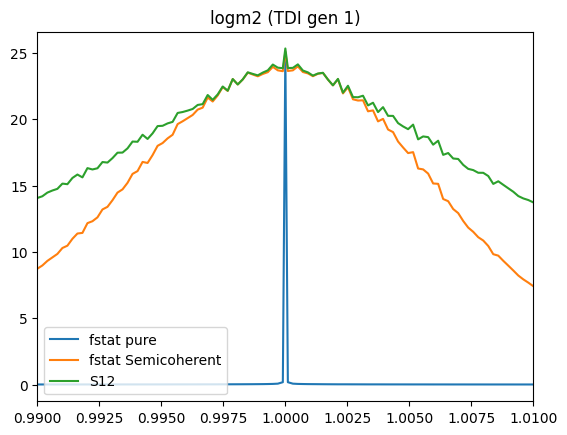

In [20]:
# plt.plot(param_range, f_stats_tm,   label='fstat timemax only')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')
# plt.plot(param_range, X_tpm, label='X timemax +phasemax')
plt.plot(param_range, Sf, label='fstat Semicoherent')
# plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Stwelve, label='S12')
# plt.plot(param_range, Ssixteen, label='S16')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
Sf

array([ 8.73771303,  8.98064387,  9.32574816,  9.58866456,  9.85082056,
       10.29733146, 10.47343735, 10.99056044, 11.3896539 , 11.43749889,
       12.17235248, 12.31765616, 12.60890627, 13.20470012, 13.40193485,
       13.90250544, 14.47587398, 14.71827675, 15.21218595, 15.88515097,
       16.09688191, 16.78757907, 16.70939561, 17.30120306, 18.00108597,
       18.21091931, 18.56390312, 18.83651386, 19.63946893, 19.85299497,
       20.08971831, 20.32761351, 20.73165285, 20.8809848 , 21.64201212,
       21.34371273, 21.80161027, 22.43348036, 22.14118747, 23.03262015,
       22.62743018, 23.00460416, 23.51957061, 23.37748146, 23.24306004,
       23.42031079, 23.55569929, 23.95700166, 23.69262807, 23.62885463,
       25.07855578, 23.64356887, 23.69246326, 23.99181498, 23.56672897,
       23.46233465, 23.25112135, 23.43140882, 23.49909657, 22.99876146,
       22.55616137, 23.02025735, 21.95243155, 22.42388601, 21.50898346,
       21.41685116, 21.43229554, 20.60364069, 20.67182338, 19.84

In [22]:
def chi2_pure(params):
    """Coherent chi^2 + suppression factor, matching loglike_pure_noise.
    Returns dict: chi_sq, suppression, beta, X_scalar (so f_pure = X_scalar*suppression)."""
    logm1, logm2, a_i, p0_i, e0_i = params
    theta = [10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]

    gwfp = loglike_p.gwf
    selected = loglike_p.mode_select if loglike_p.mode_select else loglike_p.selected_labels
    wf_comb  = loglike_p._generate_selected_waveforms(theta, selected)

    h_temp = gwfp.xp.array(loglike_p.waveform_response(*theta, T=loglike_p.T, dt=loglike_p.dt))
    h_fft  = gwfp.freq_wave(h_temp)
    mode_ffts = [gwfp.freq_wave(wf_comb[i]) for i in range(wf_comb.shape[0])]

    rho_tot = float(gwfp.xp.sqrt(gwfp.inner(h_fft, h_fft)))
    rho_m = gwfp.xp.array([float(gwfp.xp.sqrt(gwfp.inner(hf, hf))) for hf in mode_ffts])

    beta = float(gwfp.calc_beta(rho_m.max(), rho_tot))

    X_scalar = float(gwfp.inner(loglike_p.signal_fft, h_fft, return_complex=False)) / rho_tot
    X_modes = gwfp.xp.array([
        float(gwfp.inner(loglike_p.signal_fft, hf, return_complex=False)) / float(rho_m[idx])
        for idx, hf in enumerate(mode_ffts)
    ])

    chi_sq = float(gwfp.chi_sq(X_modes, rho_m))
    suppression = float(gwfp.xp.exp(-0.5 * beta * chi_sq))
    return {'chi_sq': chi_sq, 'suppression': suppression, 'beta': beta, 'X_scalar': X_scalar}

In [23]:
chi_sq_pure   = np.zeros(len(param_range))
supp_pure     = np.zeros(len(param_range))

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    out = chi2_pure(p)
    chi_sq_pure[i] = out['chi_sq']
    supp_pure[i]   = out['suppression']

In [24]:
# Check the exponential suppression factor of the semi-coherent f-stat
# Sf = S * exp(-0.5 * beta * chi_sq);  chi2_semi exposes chi_sq + suppression.
chi_sq_sc   = np.zeros(len(param_range))
suppression = np.zeros(len(param_range))
beta_sc     = np.zeros(len(param_range))

selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    logm1, logm2, a_i, p0_i, e0_i = p

    theta = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)

    out = gwf.chi2_semi(loglike_obj.signal, h, hm_arr, N_seg=6)
    chi_sq_sc[i]   = out['chi_sq']
    suppression[i] = out['suppression']
    beta_sc[i]     = out['beta']

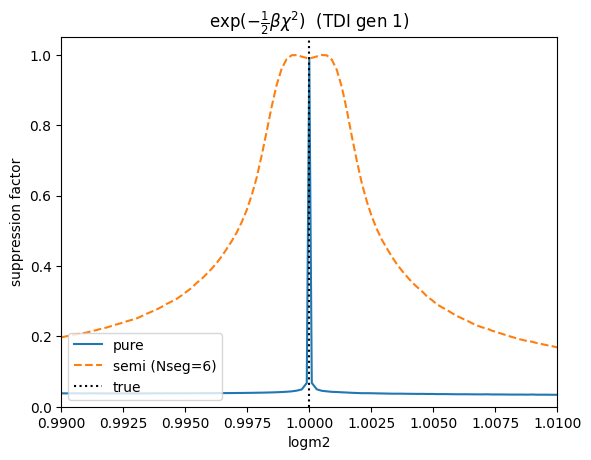

In [25]:
plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, suppression, label='semi (Nseg=6)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'$\exp(-\frac{1}{2}\beta\chi^2)$  (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

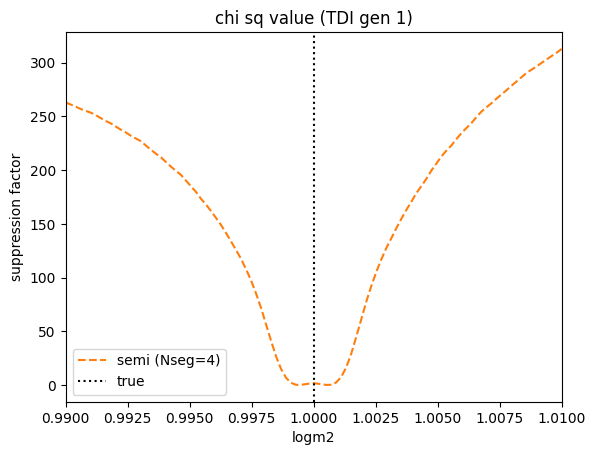

In [28]:
# plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, chi_sq_sc, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
# plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'chi sq value (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

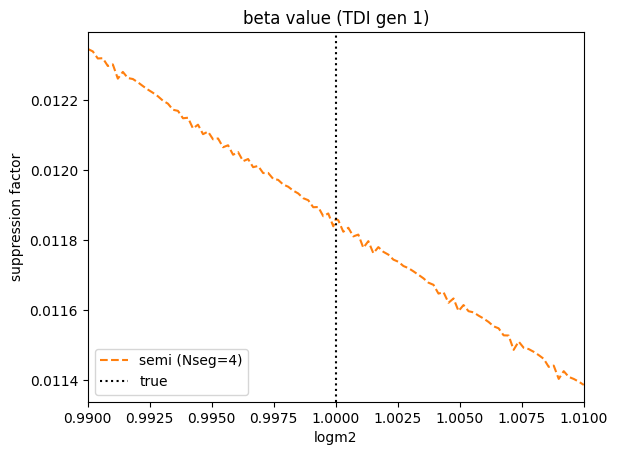

In [27]:
# plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, beta_sc, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
# plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'beta value (TDI gen 1)')
plt.legend(loc='lower left')
# plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

In [ ]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1, traj_args=[m1, m2, a, e0, xI0])


In [ ]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1.4, traj_args=[m1, m2, a, e0, xI0])
